In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
data=pd.read_csv("D:/ISE_LAB/ML-Newbie-Training/Week 1/Practice 2/elantra.csv")
print(data.head())
print(data.info())    
print(data.isnull().sum())

   Month  Year  ElantraSales  Unemployment  Queries  CPI_energy  CPI_all
0      1  2010          7690           9.7      153     213.377  217.466
1      1  2011          9659           9.1      259     229.353  221.082
2      1  2012         10900           8.2      354     244.178  227.666
3      1  2013         12174           7.9      230     242.560  231.321
4      1  2014         15326           6.6      232     247.575  234.933
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Month         50 non-null     int64  
 1   Year          50 non-null     int64  
 2   ElantraSales  50 non-null     int64  
 3   Unemployment  50 non-null     float64
 4   Queries       50 non-null     int64  
 5   CPI_energy    50 non-null     float64
 6   CPI_all       50 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 2.9 KB
None
Month           0
Year       

In [ ]:
# Trực quan hóa dữ liệu
data.sort_values(by=["Year", "Month"], inplace=True)
data.reset_index(drop=True, inplace=True)
x=data.drop(['Year','Month','ElantraSales'],axis=1)
y=data["ElantraSales"]
print(data)


    Month  Year  ElantraSales  Unemployment  Queries  CPI_energy  CPI_all
0       1  2010          7690           9.7      153     213.377  217.466
1       2  2010          7966           9.8      130     209.924  217.251
2       3  2010          8225           9.9      138     209.163  217.305
3       4  2010          9657           9.9      132     209.024  217.376
4       5  2010          9781           9.6      177     206.172  217.299
5       6  2010         14245           9.4      138     204.161  217.285
6       7  2010         18215           9.5      156     206.834  217.677
7       8  2010         15181           9.5      202     208.927  218.012
8       9  2010         10062           9.5      150     209.850  218.281
9      10  2010          9497           9.5      178     216.655  219.024
10     11  2010          8631           9.8      161     219.303  219.544
11     12  2010         13096           9.4      170     227.190  220.437
12      1  2011          9659         

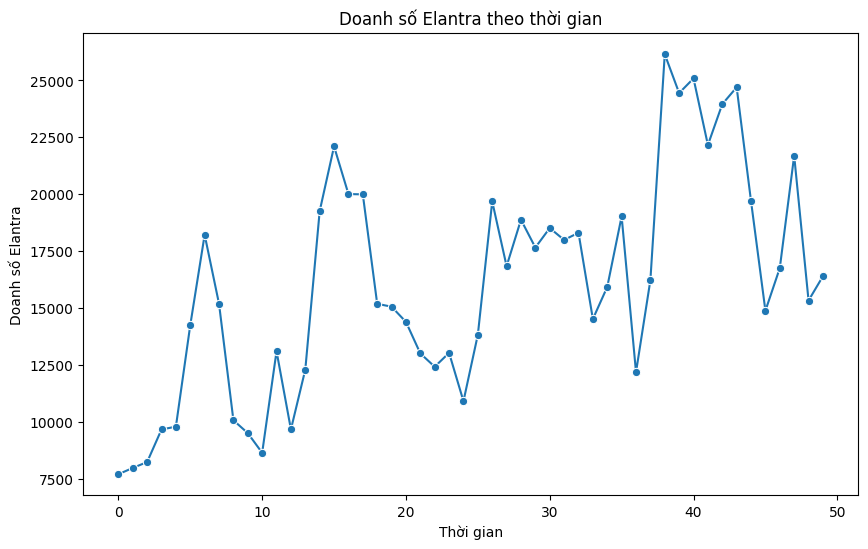

In [4]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=data.index, y=data["ElantraSales"], marker="o")
plt.title("Doanh số Elantra theo thời gian")
plt.xlabel("Thời gian")      
plt.ylabel("Doanh số Elantra")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

mask1=data.Year<2013
mask2=data.Year>=2013
x_train=x[mask1]
y_train=y[mask1]
x_test=x[mask2]
y_test=y[mask2]
print(len(x),len(x_train),len(x_test),len(y))

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#modeling
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

50 36 14 50
36    12174
37    16219
38    26153
39    24445
40    25090
41    22163
42    23958
43    24700
44    19691
45    14876
46    16751
47    21692
48    15326
49    16393
Name: ElantraSales, dtype: int64


     Test   Pred
36  12174  15129
37  16219  15944
38  26153  17834
39  24445  16486
40  25090  16519
41  22163  17765
42  23958  17429
43  24700  17597
44  19691  18044
45  14876  16520
46  16751  17193
47  21692  19043
48  15326  18419
49  16393  18137


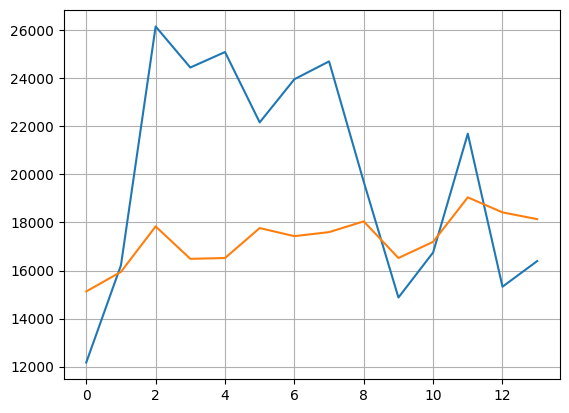

-23.15 5017.35


In [ ]:
#y_test.reset_index(drop=True , inplace=True)
Cols=pd.DataFrame({
    'Test':y_test,
    'Pred':y_pred.astype(int)
}
)
print(Cols)
r2=r2_score(y_pred,y_test)
mse=mean_squared_error(y_test,y_pred)

plt.Figure(figsize=(9,6))

sns.lineplot(data=y_test.values, markers='o')
sns.lineplot(data=y_pred,markers='o')
plt.grid()
plt.show()

import math
print(f"{r2:0.2f}",f"{math.sqrt(mse):.2f}")



     Test   Pred
36  12174   9547
37  16219  14500
38  26153  18520
39  24445  18528
40  25090  18422
41  22163  20186
42  23958  22288
43  24700  20552
44  19691  17268
45  14876  14428
46  16751  16029
47  21692  20546
48  15326  16195
49  16393  16978


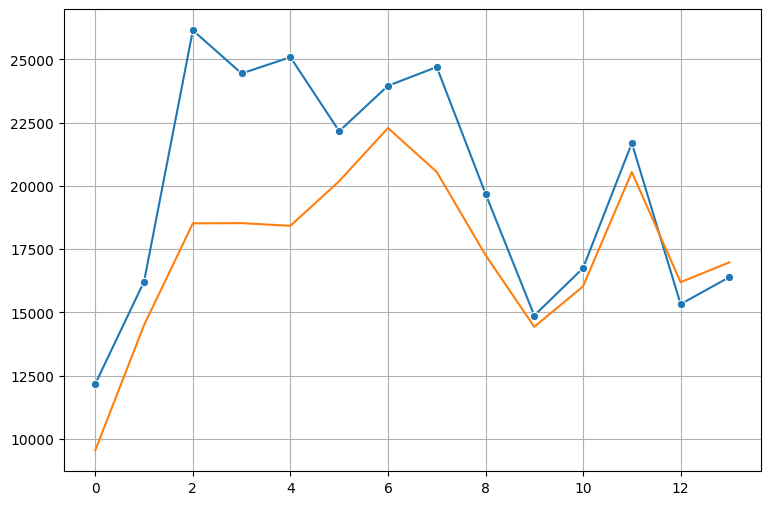

0.35 3590.37


In [ ]:
data_endc=data
month=data['Month']
month_endc=pd.get_dummies(data=month,columns=['Month'],drop_first=True,dtype=int,prefix='Month')
x=data_endc.drop(['Year','Month','ElantraSales'],axis=1)
y=data_endc["ElantraSales"]

mask1=data_endc.Year<2013
mask2=data_endc.Year>=2013
x_train=x[mask1]
y_train=y[mask1]
x_test=x[mask2]
y_test=y[mask2]
month_train=month_endc[mask1]
month_test=month_endc[mask2]


x_train_sl=scaler.fit_transform(x_train)
x_test_sl=scaler.transform(x_test)

x_train= pd.DataFrame(x_train_sl, columns=x.columns, index=x_train.index)
x_test= pd.DataFrame(x_test_sl, columns=x.columns, index=x_test.index)

x_train=pd.concat([x_train,month_train],axis=1)
x_test=pd.concat([x_test,month_test],axis=1)

#modeling
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
Cols=pd.DataFrame({
    'Test':y_test,
    'Pred':y_pred.astype(int)
}
)

print(Cols)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

plt.figure(figsize=(9,6))

sns.lineplot(data=y_test.values, marker='o')
sns.lineplot(data=y_pred,markers='o')
plt.grid()
plt.show()

import math
print(f"{r2:0.2f}",f"{math.sqrt(mse):.2f}")



In [ ]:
Test=model.predict(x_train)
r2=r2_score(y_train,Test)
print(r2)


0.8192642006018234


     Test   Pred
36  12174   9547
37  16219  14500
38  26153  18520
39  24445  18528
40  25090  18422
41  22163  20186
42  23958  22288
43  24700  20552
44  19691  17268
45  14876  14428
46  16751  16029
47  21692  20546
48  15326  16195
49  16393  16978


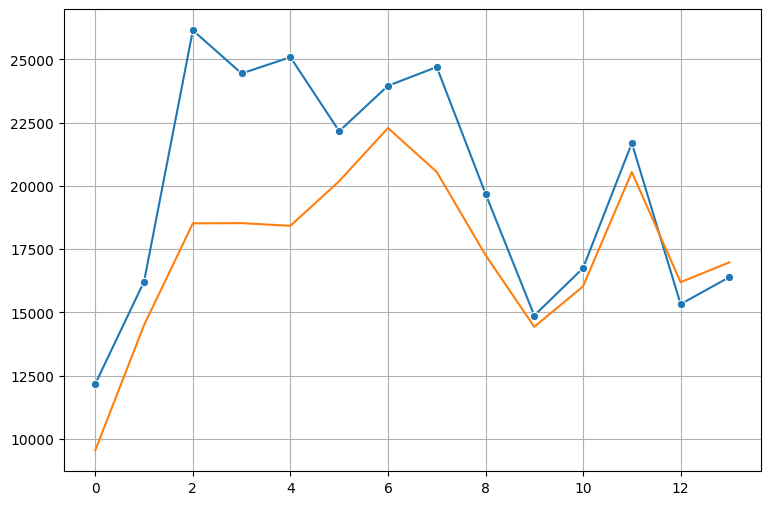

0.35 3590.37


In [8]:
data_endc=pd.get_dummies(data=data,columns=['Month'],drop_first=True,dtype=int,prefix='Month')
x=data_endc.drop(['Year','ElantraSales'],axis=1)
y=data_endc["ElantraSales"]

mask1=data_endc.Year<2013
mask2=data_endc.Year>=2013
x_train=x[mask1]
y_train=y[mask1]
x_test=x[mask2]
y_test=y[mask2]

x_train=scalaer.fit_transform(x_train)
x_test=scalaer.transform(x_test)


#modeling
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
#y_test.reset_index(drop=True , inplace=True)
Cols=pd.DataFrame({
    'Test':y_test,
    'Pred':y_pred.astype(int)
}
)
print(Cols)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

plt.figure(figsize=(9,6))

sns.lineplot(data=y_test.values, marker='o')
sns.lineplot(data=y_pred,markers='o')
plt.grid()
plt.show()

import math
print(f"{r2:0.2f}",f"{math.sqrt(mse):.2f}")

